#**[최신기술 1]**

## 1. 기술 소개

- 기술명: MapReduce

- 설명: MapReduce는 병렬 처리를 사용하여 대규모 데이터 처리 속도를 높이는 프로그래밍 모델로, 데이터를 더 작은 작업으로 나누어 여러 노드에서 처리한 후 결과를 집계한다. 입력 데이터를 여러 부분으로 분할하고, 각 부분에서 같은 방식으로 계산한 뒤, 마지막에 결과를 집계한다. 이 구조는 대용량 로그 분석, 검색어 빈도 계산, 문서 색인 생성처럼 많은 데이터를 빠르게 처리해야 하는 작업에 적합하다. 이번 구현에서는 전체 분산 시스템을 만들기보다, 데이터 분할과 결과 집계라는 핵심 아이디어를 단일 프로그램에서 간단히 구현한다.

- 활용 사례:
1. 웹 검색엔진의 단어 색인 생성
2. 서버 로그에서 가장 많이 발생한 키워드 추출
3. SNS 게시글에서 자주 등장하는 단어 분석
4. 대량 텍스트 데이터의 통계 집계

- 참고 자료(논문, 기사 등):

[1] Jeffrey Dean, Sanjay Ghemawat, “MapReduce: Simplified Data Processing on Large Clusters,” 2004.

[2] IBM, “What is Hadoop?”, Available: https://www.ibm.com/topics/hadoop

[3] “Hadoop 및 MapReduce 개념 정리,” Available: https://12bme.tistory.com/154

[4] IBM, “MapReduce,” Available: https://www.ibm.com/kr-ko/think/topics/mapreduce

[5] “MapReduce 개념 정리,” Available: https://velog.io/@minbrok/MapReduce

## 2. 사용된 자료구조 또는 알고리즘

- 자료구조 또는 알고리즘 명칭: Divide & Conquer, Heap(Priority Queue)

- 해당 자료구조/알고리즘에 대한 설명(500자 이상):

Divide & Conquer는 큰 문제를 작은 문제로 나누어 각각 해결한 뒤, 그 결과를 합쳐 전체 답을 구하는 알고리즘 설계 방식이다. 대표적으로 배열을 반으로 나누어 처리하는 방식이 있다. 이 방법은 문제를 작은 단위로 분해하므로 구조가 단순해지고, 재귀적으로 구현하기 쉬우며, 병렬 처리와도 잘 맞는다. MapReduce의 핵심 아이디어도 이와 매우 비슷하다. 전체 데이터를 여러 조각으로 나눈 뒤, 각 조각에 대해 같은 작업을 수행하고, 마지막에 결과를 합치는 구조이기 때문이다.
Heap은 우선순위가 높은 데이터를 빠르게 꺼내기 위한 자료구조이다. 일반적으로 최소 힙 또는 최대 힙 형태로 사용되며, 삽입과 삭제가 효율적이다. 특히 Top-K 문제처럼 “가장 큰 값 K개” 또는 “가장 작은 값 K개”를 뽑아야 하는 경우에 매우 유용하다. 모든 데이터를 정렬하면 비용이 크지만, 힙을 사용하면 필요한 개수만 효율적으로 선택할 수 있다. 이번 기술에서는 먼저 Divide & Conquer로 데이터를 나누어 부분 빈도수를 계산하고, Heap으로 가장 많이 등장한 단어를 빠르게 추출한다.

- 기술1에서 해당 자료구조/알고리즘이 필요한 이유:
1. Divide & Conquer: 큰 텍스트 데이터를 작은 구간으로 나누어 부분 문제를 독립적으로 처리할 수 있기 때문
2. Heap: 단어 빈도 결과에서 상위 K개를 빠르게 찾기 위해 필요하기 때문

- 기술1에서 해당 자료구조/알고리즘이 적용되는 핵심 원리(구조도 또는 흐름도 그림 포함):
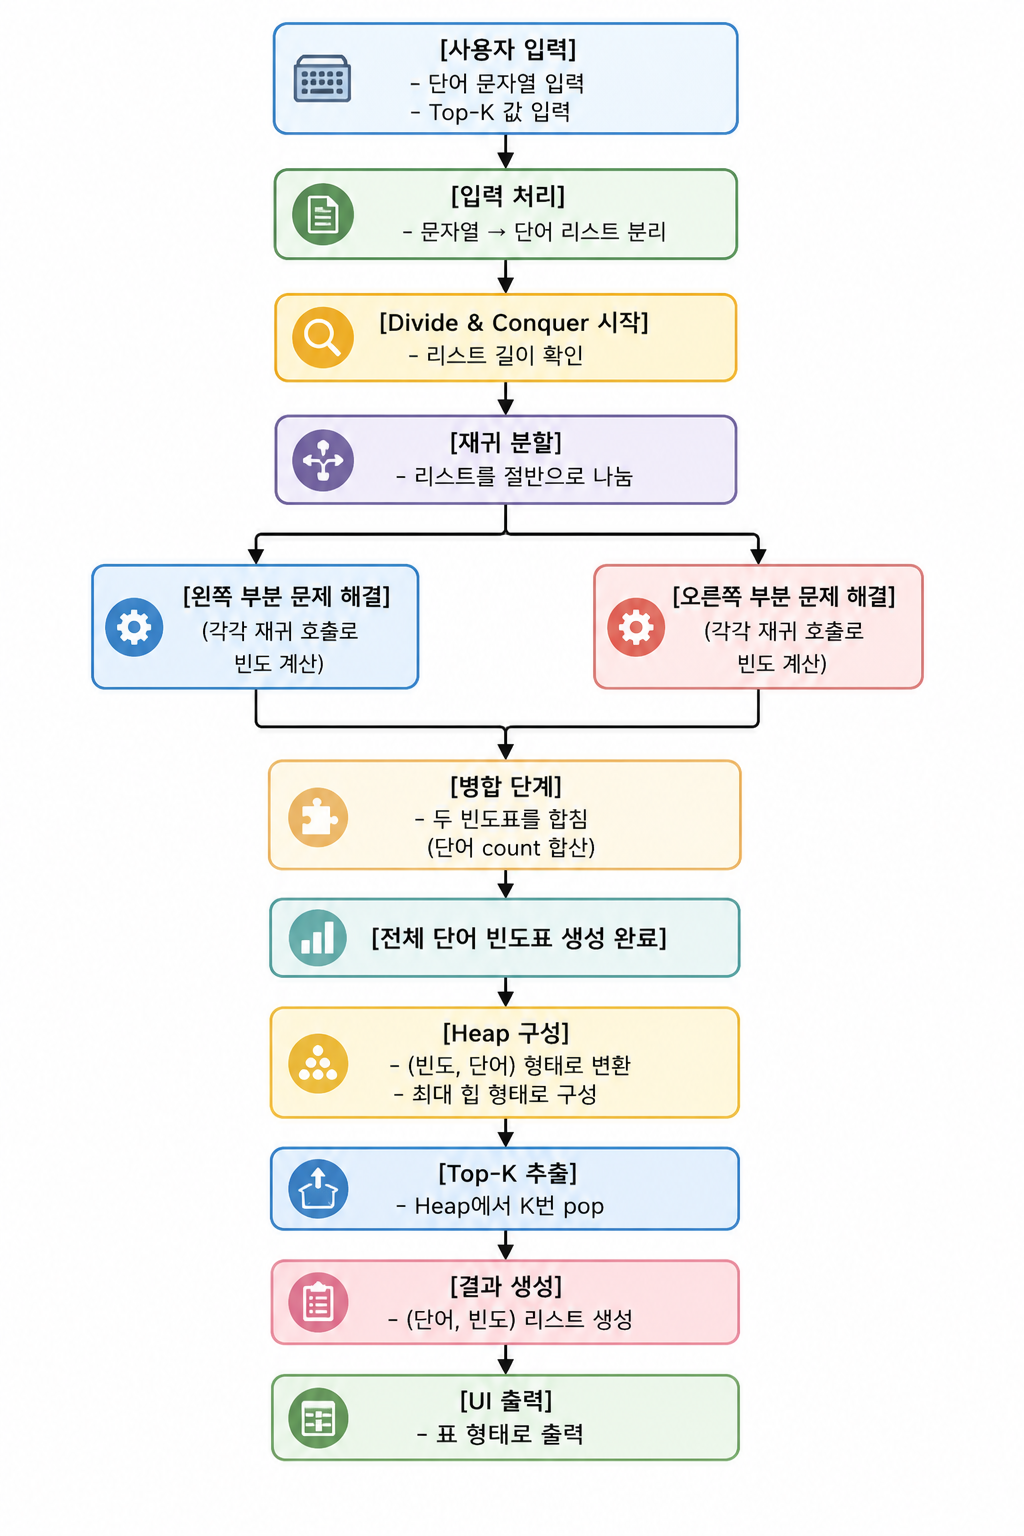

##3. 코드 구현

- 구현할 부분 한 줄 소개: 텍스트를 재귀적으로 분할해 단어 빈도를 계산하고, 힙으로 가장 많이 나온 단어 상위 K개를 뽑는다.

- 구현할 부분에 대한 자세한 설명(동작 방식 등): 이 코드는 전체 MapReduce 시스템을 구현하지는 않는다. 대신 핵심 아이디어만 구현한다.
1. 입력받은 단어 리스트를 Divide & Conquer 방식으로 반씩 나눈다.
2. 각 작은 구간에서 단어 빈도를 계산한다.
3. 왼쪽 결과와 오른쪽 결과를 합쳐 전체 빈도표를 만든다.
4. 최종적으로 heapq를 사용해 빈도가 높은 단어 Top-K를 출력한다. 이 방식은 대용량 데이터를 다루는 구조를 이해하는 데 적합하며, 분할 정복과 힙의 실제 활용 예시로도 쓸 수 있다.

- 입출력 방식 설명:
1. 입력
- 입력 칸: 공백으로 구분된 단어 N개
- Top-K 조절바: 출력할 상위 개수 K
2. 출력
- 빈도수가 높은 순서대로 상위 K개의 단어와 빈도를 출력

- 입출력 예시 1(예시대로 동작하지 않을 경우 감점):
1. 입력
- apple banana apple orange banana apple grape orange apple banana
- 3
2. 출력
- apple 4
- banana 3
- orange 2
- 입출력 예시 2:
1. 입력
- cat dog cat bird dog cat fish bird
- 2
2. 출력
- cat 3
- bird 2

**버전 1**

In [ ]:
import heapq
from collections import defaultdict
import ipywidgets as widgets
from IPython.display import display, HTML

# ---------- 알고리즘 부분 ----------

def divide_and_conquer_count(words):
    if len(words) == 1:
        counter = defaultdict(int)
        counter[words[0]] = 1
        return counter

    mid = len(words) // 2
    left = divide_and_conquer_count(words[:mid])
    right = divide_and_conquer_count(words[mid:])

    for word, count in right.items():
        left[word] += count

    return left

def top_k_words(word_counts, k):
    heap = [(-count, word) for word, count in word_counts.items()]
    heapq.heapify(heap)

    result = []
    for _ in range(min(k, len(heap))):
        neg_count, word = heapq.heappop(heap)
        result.append((word, -neg_count))

    return result

# ---------- UI 스타일 ----------

def show_title():
    display(HTML("""
    <h1 style='color:#4CAF50; text-align:center;'>
        🌟 MapReduce Simulator (Divide & Conquer + Heap) 🌟
    </h1>
    """))

def show_result(results):
    html = """
    <div style='border:2px solid #4CAF50; border-radius:15px; padding:15px; background:#f9fff9;'>
    <h3 style='color:#2E7D32;'>📊 Top-K 결과</h3>
    <table style='width:100%; border-collapse: collapse;'>
    <tr style='background:#4CAF50; color:white;'>
        <th style='padding:8px;'>단어</th>
        <th style='padding:8px;'>빈도</th>
    </tr>
    """

    for word, count in results:
        html += f"""
        <tr style='text-align:center; color:black;'>
            <td style='padding:8px;'>{word}</td>
            <td style='padding:8px;'>{count}</td>
        </tr>
        """

    html += "</table></div>"
    display(HTML(html))

# ---------- 인터페이스 ----------

show_title()

text_input = widgets.Textarea(
    placeholder="단어들을 공백으로 입력하세요 (예: apple banana apple)",
    layout=widgets.Layout(width='100%', height='100px')
)

k_input = widgets.IntSlider(
    value=3,
    min=1,
    max=10,
    step=1,
    description='Top-K:',
    style={'description_width': 'initial'}
)

run_button = widgets.Button(
    description="🚀 실행하기",
    button_style='success'
)

output = widgets.Output()

# ---------- 실행 로직 ----------

def on_click(b):
    with output:
        output.clear_output()

        words = text_input.value.split()
        if not words:
            print("❗ 단어를 입력하세요")
            return

        counts = divide_and_conquer_count(words)
        results = top_k_words(counts, k_input.value)

        show_result(results)

run_button.on_click(on_click)

# ---------- UI 출력 ----------

display(widgets.VBox([
    widgets.HTML("<h3>📥 입력</h3></div>"),
    text_input,
    k_input,
    run_button,
    output
]))

**버전 2**

In [ ]:
from IPython.display import display, HTML

html_code = """
<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body {
    margin:0;
    font-family: 'Segoe UI';
    background: linear-gradient(135deg, #0f172a, #1e293b);
    color:white;
}

.container {
    max-width: 1000px;
    margin:auto;
    padding:20px;
}

h1 {
    text-align:center;
    color:#4ade80;
}

.card {
    background:#1e293b;
    padding:20px;
    border-radius:15px;
    margin-top:20px;
    box-shadow:0 0 15px rgba(0,0,0,0.3);
}

textarea {
    width:100%;
    height:100px;
    border-radius:10px;
    padding:10px;
    border:none;
    font-size:14px;
}

button {
    width:100%;
    padding:12px;
    border:none;
    border-radius:10px;
    background:#22c55e;
    color:white;
    font-weight:bold;
    margin-top:10px;
    cursor:pointer;
}

button:hover {
    background:#16a34a;
}

.result-row {
    display:flex;
    justify-content:space-between;
    padding:8px;
    border-radius:8px;
    margin-top:5px;
}

.success {
    background:#14532d;
}

.chart-container {
    margin-top:20px;
}

@media (max-width:600px){
    .container{
        padding:10px;
    }
}
</style>
</head>

<body>

<div class="container">

<h1>🌟 MapReduce Simulator</h1>

<div class="card">
<h3>📥 데이터 입력</h3>
<textarea id="text" placeholder="단어 입력 (예: apple banana apple orange)"></textarea>

<label>Top-K</label>
<input type="range" id="k" min="1" max="10" value="3" oninput="kval.innerText=this.value">
<span id="kval">3</span>

<button onclick="run()">🚀 실행</button>
</div>

<div class="card">
<h3>📊 결과</h3>
<div id="result"></div>
<canvas id="chart"></canvas>
</div>

</div>

<script>
function divide(words){
    if(words.length === 1){
        let obj = {};
        obj[words[0]] = 1;
        return obj;
    }

    let mid = Math.floor(words.length/2);
    let left = divide(words.slice(0,mid));
    let right = divide(words.slice(mid));

    for(let w in right){
        left[w] = (left[w] || 0) + right[w];
    }
    return left;
}

function topK(counts, k){
    let arr = Object.entries(counts);
    arr.sort((a,b)=>b[1]-a[1]);
    return arr.slice(0,k);
}

function run(){
    let text = document.getElementById("text").value;
    let words = text.trim().split(/\\s+/);

    if(words.length === 0 || words[0] === ""){
        alert("단어를 입력하세요!");
        return;
    }

    let counts = divide(words);
    let k = parseInt(document.getElementById("k").value);
    let result = topK(counts, k);

    let html = "";
    let labels = [];
    let data = [];

    result.forEach(([word,count])=>{
        html += `<div class="result-row success">${word} <b>${count}</b></div>`;
        labels.push(word);
        data.push(count);
    });

    document.getElementById("result").innerHTML = html;

    drawChart(labels, data);
}

let chart;

function drawChart(labels, data){
    if(chart) chart.destroy();

    const ctx = document.getElementById('chart');

    chart = new Chart(ctx, {
        type: 'bar',
        data: {
            labels: labels,
            datasets: [{
                label: '빈도',
                data: data
            }]
        },
        options: {
            responsive:true
        }
    });
}
</script>

</body>
</html>
"""

display(HTML(html_code))

#**[최신기술 2]**

## 1. 기술 소개

- 기술명: Behavior Tree

- 설명:

Behavior Tree(행동 트리)는 로봇 공학과 게임 AI에서 널리 사용되는 의사결정 구조로, 트리(Tree) 형태를 통해 행동을 계층적으로 구성하고 실행하는 방식이다. 각 노드는 특정 조건이나 행동을 의미하며, 부모-자식 관계를 통해 복잡한 행동을 단순한 규칙의 조합으로 표현할 수 있다. 특히 Selector, Sequence와 같은 제어 노드를 통해 "대안 선택"과 "순차 실행"을 구조적으로 구현할 수 있어, 기존의 복잡한 상태 머신보다 직관적이고 확장성이 높다. 실제 산업에서도 자율주행 로봇, 게임 캐릭터 AI, 서비스 로봇의 행동 제어 등 다양한 영역에서 안정적인 의사결정 구조로 인정받고 있다.

- 활용 사례:
1. 게임 AI 캐릭터 행동 제어 (적 탐색, 공격, 도망)
2. 자율주행 로봇의 행동 결정 (이동, 장애물 회피)
3. 서비스 로봇의 작업 흐름 제어 (주문 → 이동 → 제공)

- 참고 자료(논문, 기사 등):

[1] Michele Colledanchise, Petter Ögren, Behavior Trees in Robotics and AI, CRC Press, 2018.

[2] “행동트리 모델의 이해,” Available: https://velog.io/@ryan_ur/2-11%EA%B0%95-%ED%96%89%EB%8F%99%ED%8A%B8%EB%A6%AC-%EB%AA%A8%EB%8D%B8%EC%9D%98-%EC%9D%B4%ED%95%B4

[3] LINE Corporation, “Behavior Tree,” Available: https://engineering.linecorp.com/ko/blog/behavior-tree

## 2. 사용된 자료구조 또는 알고리즘

- 자료구조 또는 알고리즘 명칭: DFS(깊이 우선 탐색) + Tree(트리)

- 해당 자료구조/알고리즘에 대한 설명(500자 이상):

트리(Tree)는 노드와 간선로 구성된 비선형 자료구조로, 하나의 Root에서 시작하여 자식 노드들이 계층적으로 연결되는 구조를 가진다. 이러한 구조는 부모-자식 관계를 명확하게 표현할 수 있어 계층적 시스템을 모델링하는 데 적합하다. 각 Node는 자신의 children을 가지며, 더 이상 자식이 없는 리프 노드는 실제 실행 단위를 나타낸다. Behavior Tree는 이러한 Tree 구조를 기반으로 설계되며, Selector나 Sequence와 같은 제어 노드는 내부 노드로, 실제 행동(Action)은 리프 노드로 구성된다. 따라서 Tree 구조는 Behavior Tree에서 복잡한 행동을 계층적으로 표현하고 관리하기 위한 핵심 기반이 된다.

DFS(깊이 우선 탐색)는 트리나 그래프에서 하나의 경로를 리프 노드까지 깊게 탐색한 뒤, 더 이상 진행할 수 없으면 이전 분기점으로 돌아가 다른 경로를 탐색하는 알고리즘이다. DFS는 재귀 또는 Stack을 통해 구현되며, “한 경로를 끝까지 탐색 → 실패 시 다른 경로로 이동”이라는 특징을 가진다. Behavior Tree의 실행 방식은 이러한 DFS 구조와 직접적으로 대응된다. Selector 노드는 첫 번째 자식 노드를 실행하고, 해당 노드가 하위 트리를 포함할 경우 그 내부까지 재귀적으로 탐색한다. 만약 결과가 FAILURE라면 다음 자식 노드로 이동하며, SUCCESS가 반환될 때까지 이 과정을 반복한다. 이는 DFS가 한 branch를 끝까지 탐색한 후 실패 시 다른 branch로 이동하는 방식과 동일하다. 실제로 Michele Colledanchise와 Petter Ögren(2018)은 Behavior Tree의 실행을 트리의 재귀적 순회(recursive traversal)로 설명하고 있다. 이러한 실행 방식은 한 경로를 따라 하위 노드를 끝까지 탐색한 뒤, 결과를 부모 노드로 반환하는 구조를 가지므로 DFS의 동작 방식과 유사한 특징을 보인다. 이에 따라 Behavior Tree의 실행 과정을 DFS로 모델링할 수 있다고 판단하였으며, 본 탐구에서는 이를 바탕으로 DFS 기반으로 Behavior Tree를 구현하였다.

- 기술2에서 해당 자료구조/알고리즘이 필요한 이유:

1. Tree: Behavior Tree는 Selector(내부 노드)와 Action(리프 노드)을 계층적으로 연결하는 구조이므로, 트리 자료구조로 노드 간 관계를 명확하게 표현해야 한다.
2. DFS: Selector 노드는 자식 노드를 순서대로, 재귀적으로(깊이 우선으로) 실행한다. 이는 DFS의 탐색 방식과 정확히 같으므로, DFS가 Behavior Tree의 실행 흐름을 가장 자연스럽게 설명한다.

- 기술2에서 해당 자료구조/알고리즘이 적용되는 핵심 원리(구조도 또는 흐름도 그림 포함):

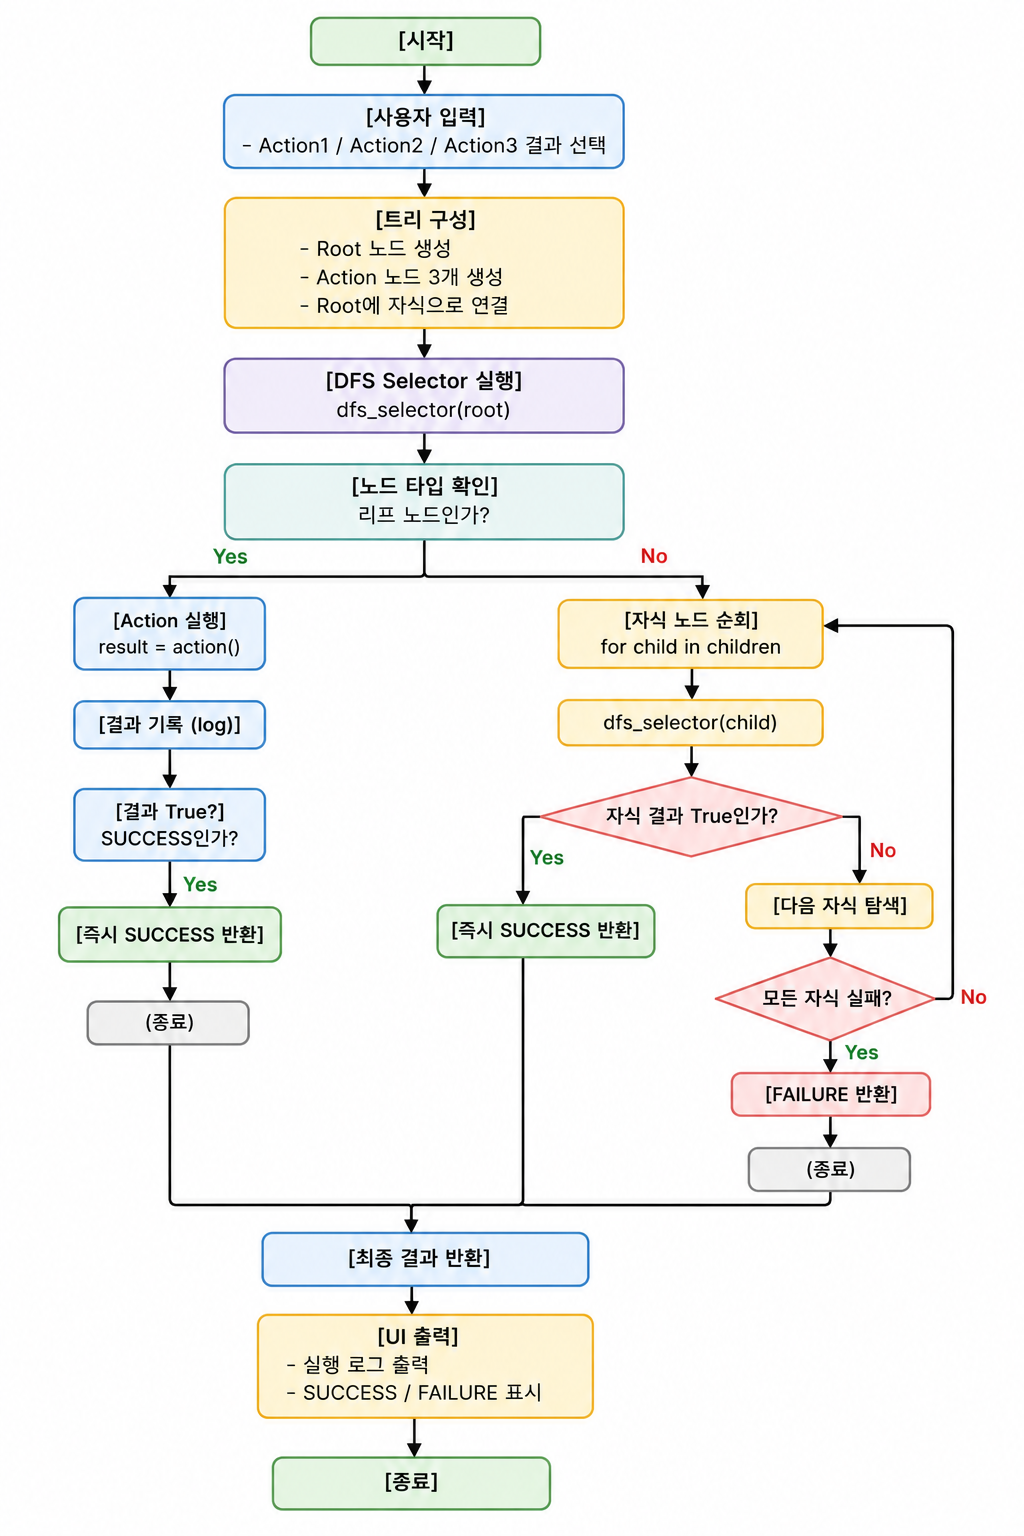

##3. 코드 구현

- 구현할 부분 한 줄 소개:

트리(Tree) 자료구조로 Behavior Tree 노드를 구성하고, DFS 재귀 탐색으로 Selector를 실행한다.

- 구현할 부분에 대한 자세한 설명(동작 방식 등):

이 코드는 Behavior Tree의 Selector 노드를 Tree 자료구조와 DFS 알고리즘으로 구현한다. 먼저 모든 노드를 Node 클래스로 표현하며, 각 노드는 이름과 자식 노드 리스트를 가진다. Action 노드(리프 노드)는 자식이 없고 실행 결과(True/False)를 가진다. Selector 노드는 자식 노드들을 DFS 방식으로 재귀 실행하며, 하나라도 SUCCESS이면 즉시 SUCCESS를 반환하고, 모두 FAILURE이면 FAILURE를 반환한다. 이 구조는 트리의 계층 관계를 코드에서 직접 표현하며, DFS 재귀 호출이 실행 흐름의 핵심이다.
또한 DFS와 Tree 구조를 활용하여 실행 구조를 보다 단순하고 직관적으로 표현하기 위해 Running 상태를 제외한 non-reactive Behavior Tree를 사용하였다.

- 입출력 방식 설명:
1. 입력
- 여러 행동 함수 버튼 선택(True: 성공, False: 실패)
2. 출력
- 최종 행동 결과 (Success / Failure)

- 입출력 예시 1(예시대로 동작하지 않을 경우 감점):
1. 입력 (행동 결과):
- [False, False, True]
2. 출력:
- Success

- 입출력 예시 2:
1. 입력:
- [False, False, False]
2. 출력:
- Failure

**버전 1**

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ---------- Node 정의 ----------

class Node:
    def __init__(self, name, action=None):
        self.name = name
        self.children = []
        self.action = action

    def add_child(self, node):
        self.children.append(node)


# ---------- DFS Selector ----------

def dfs_selector(node, log):
    if node.action is not None:
        result = node.action()
        log.append((node.name, result))
        return result

    for child in node.children:
        if dfs_selector(child, log):
            return True
    return False


# ---------- UI 스타일 ----------

def show_title():
    display(HTML("""
    <h1 style='text-align:center; color:#1976D2;'>
        🤖 Behavior Tree Simulator (DFS)
    </h1>
    """))

def show_tree():
    display(HTML("""
    <pre style='font-size:16px; background:#f4f4f4; padding:10px; border-radius:10px;'>
        Selector (Root)
        ├── Action1
        ├── Action2
        └── Action3
    </pre>
    """))

def show_result(log, final_result):
    html = """
    <div style='border:2px solid #1976D2; border-radius:15px; padding:15px; background:#f0f7ff;'>
    <h3>📊 실행 과정</h3>
    """

    for name, result in log:
        color = "#4CAF50" if result else "#F44336"
        status = "SUCCESS" if result else "FAILURE"

        html += f"""
        <div style='margin:5px; padding:8px; border-radius:8px; background:{color}; color:white;'>
            {name} → {status}
        </div>
        """

    final_color = "#4CAF50" if final_result else "#F44336"
    final_text = "SUCCESS" if final_result else "FAILURE"

    html += f"""
    <h2 style='color:{final_color};'>최종 결과: {final_text}</h2>
    </div>
    """

    display(HTML(html))


# ---------- 인터페이스 ----------

show_title()
show_tree()

action1 = widgets.ToggleButtons(
    options=['FAIL', 'SUCCESS'],
    description='Action1:',
    style={'description_width': 'initial'}
)

action2 = widgets.ToggleButtons(
    options=['FAIL', 'SUCCESS'],
    description='Action2:',
    style={'description_width': 'initial'}
)

action3 = widgets.ToggleButtons(
    options=['FAIL', 'SUCCESS'],
    description='Action3:',
    style={'description_width': 'initial'}
)

run_button = widgets.Button(
    description="🚀 실행",
    button_style='primary'
)

output = widgets.Output()


# ---------- 실행 로직 ----------

def run_bt(b):
    with output:
        clear_output()

        # 트리 구성
        root = Node("Root")

        a1 = Node("Action1", action=lambda: action1.value == "SUCCESS")
        a2 = Node("Action2", action=lambda: action2.value == "SUCCESS")
        a3 = Node("Action3", action=lambda: action3.value == "SUCCESS")

        root.add_child(a1)
        root.add_child(a2)
        root.add_child(a3)

        log = []
        result = dfs_selector(root, log)

        show_result(log, result)

run_button.on_click(run_bt)


# ---------- UI 출력 ----------

display(widgets.VBox([
    widgets.HTML("<h3>🎮 행동 결과 설정</h3>"),
    action1,
    action2,
    action3,
    run_button,
    output
]))

**버전2**

In [ ]:
from IPython.display import display, HTML

html_code = """
<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<style>
body {
    font-family: Arial;
    margin: 0;
    background: #0f172a;
    color: white;
}

.container {
    max-width: 900px;
    margin: auto;
    padding: 20px;
}

h1 {
    text-align: center;
    color: #38bdf8;
}

.card {
    background: #1e293b;
    padding: 20px;
    border-radius: 15px;
    margin-top: 20px;
}

.tree {
    text-align: center;
    background: #111827;
    padding: 15px;
    border-radius: 10px;
}

.row {
    display: flex;
    gap: 10px;
    flex-wrap: wrap;
}

.action {
    flex: 1;
}

select, button {
    width: 100%;
    padding: 10px;
    margin-top: 10px;
    border-radius: 10px;
    border: none;
}

.run {
    background: #3b82f6;
    color: white;
    font-weight: bold;
}

.success {
    background: #22c55e;
    padding: 10px;
    border-radius: 8px;
    margin-top: 5px;
}

.fail {
    background: #ef4444;
    padding: 10px;
    border-radius: 8px;
    margin-top: 5px;
}

@media (max-width: 600px) {
    .row {
        flex-direction: column;
    }
}
</style>
</head>

<body>

<div class="container">

<h1>🤖 Behavior Tree Simulator</h1>

<div class="card">
<div class="tree">
Selector (Root)<br>
├ Action1<br>
├ Action2<br>
└ Action3
</div>
</div>

<div class="card">
<h3>🎮 행동 설정</h3>

<div class="row">
<div class="action">
<label>Action1</label>
<select id="a1">
<option>FAIL</option>
<option>SUCCESS</option>
</select>
</div>

<div class="action">
<label>Action2</label>
<select id="a2">
<option>FAIL</option>
<option>SUCCESS</option>
</select>
</div>

<div class="action">
<label>Action3</label>
<select id="a3">
<option>FAIL</option>
<option>SUCCESS</option>
</select>
</div>
</div>

<button class="run" onclick="runBT()">🚀 실행</button>

<div id="result"></div>

</div>

</div>

<script>
function dfs(actions) {
    let log = [];

    for (let i = 0; i < actions.length; i++) {
        let res = actions[i] === "SUCCESS";
        log.push({name: "Action" + (i+1), result: res});
        if (res) return {log, result: true};
    }

    return {log, result: false};
}

function runBT() {
    let a1 = document.getElementById("a1").value;
    let a2 = document.getElementById("a2").value;
    let a3 = document.getElementById("a3").value;

    let {log, result} = dfs([a1, a2, a3]);

    let html = "<div class='card'><h3>📊 실행 결과</h3>";

    log.forEach(item => {
        let color = item.result ? "success" : "fail";
        let text = item.result ? "SUCCESS" : "FAILURE";

        html += `<div class="${color}">${item.name} → ${text}</div>`;
    });

    html += `<h2 style="color:${result ? '#22c55e' : '#ef4444'}">
    최종 결과: ${result ? 'SUCCESS' : 'FAILURE'}
    </h2></div>`;

    document.getElementById("result").innerHTML = html;
}
</script>

</body>
</html>
"""

display(HTML(html_code))